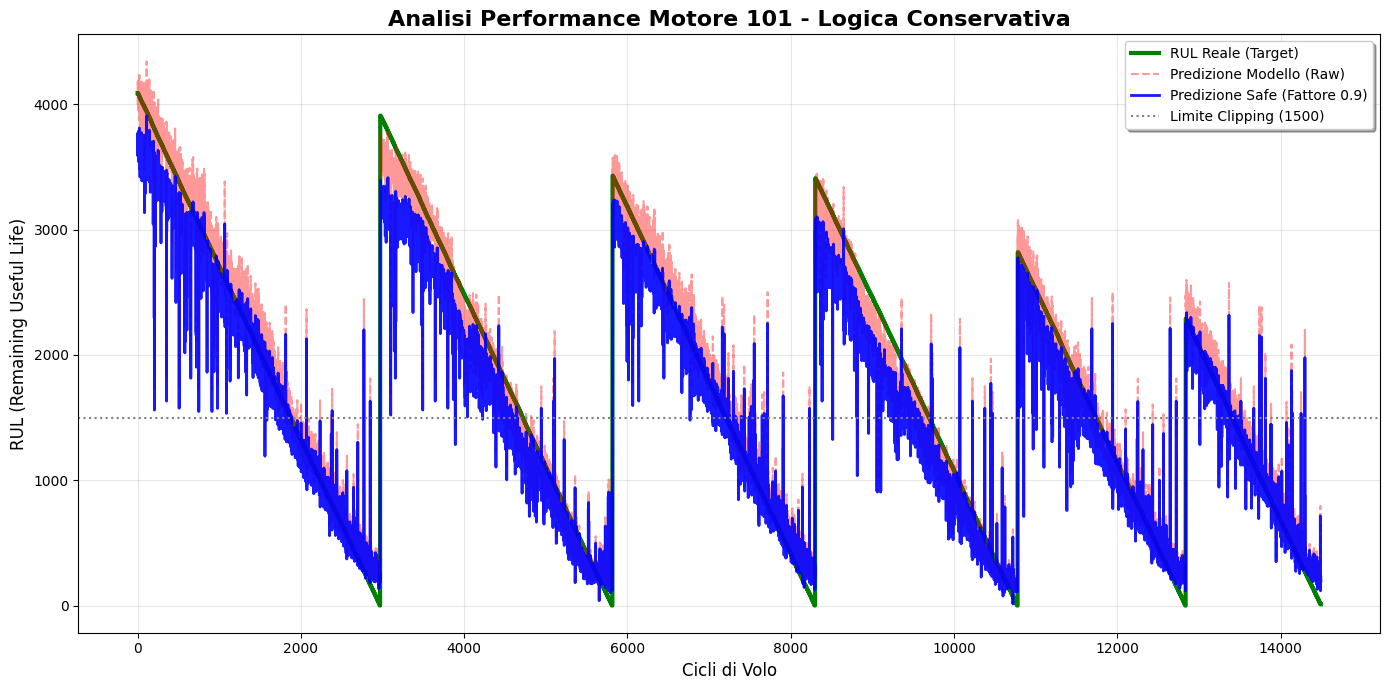

In [8]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import joblib

# --- 1. FUNZIONE GRAFICA AGGIORNATA ---
def plot_prediction_vs_rul_safe(y_true, y_pred, engine_id="N/A", safety_factor=0.90, clip_limit=1500):
    """
    Visualizzazione coerente con l'addestramento:
    Usa un moltiplicatore (safety_factor) per la linea blu.
    """
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    
    # Applichiamo lo stesso margine usato nel tuo training
    y_pred_safe = y_pred * safety_factor 

    plt.figure(figsize=(14, 7))
    
    # RUL Reale
    plt.plot(y_true, label='RUL Reale (Target)', color='green', linewidth=3)
    
    # Predizione Pura (Raw)
    plt.plot(y_pred, label='Predizione Modello (Raw)', color='red', alpha=0.4, linestyle='--', linewidth=1.5)
    
    # Predizione Conservativa (quella che ha generato il tuo score di 29.78)
    plt.plot(y_pred_safe, label=f'Predizione Safe (Fattore {safety_factor})', color='blue', alpha=0.9, linewidth=2)

    if clip_limit:
        plt.axhline(clip_limit, color='gray', linestyle=':', label=f'Limite Clipping ({clip_limit})')

    plt.title(f'Analisi Performance Motore {engine_id} - Logica Conservativa', fontsize=16, fontweight='bold')
    plt.xlabel('Cicli di Volo', fontsize=12)
    plt.ylabel('RUL (Remaining Useful Life)', fontsize=12)
    plt.legend(loc='upper right', frameon=True, shadow=True)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

# --- 2. ESECUZIONE SUL TUO MODELLO ---
df = pd.read_csv('data_elaborated/train/train_with_residuals.csv')
model = joblib.load('models/model_Cycles_to_HPT_SV.pkl')

# Test sul motore 101
engine_id = 101
engine_data = df[df['ESN'] == engine_id].sort_values('Cycles_Since_New')

# Feature selection dinamica
features = [c for c in engine_data.columns if 'Sensed' in c or '_res' in c]
features = [f for f in features if f not in ['ESN', 'Cycles_Since_New', 'Snapshot', 
                                             'Cycles_to_WW', 'Cycles_to_HPC_SV', 'Cycles_to_HPT_SV']]

y_true = engine_data['Cycles_to_HPT_SV']
y_pred = model.predict(engine_data[features])

# Lancio del grafico con il tuo margine 0.90
plot_prediction_vs_rul_safe(y_true, y_pred, engine_id=engine_id, safety_factor=0.90)
